In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx


Necessary Library

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
df = pd.read_excel('/kaggle/input/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx')
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Data Cleanning and Preprocessing

In [5]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

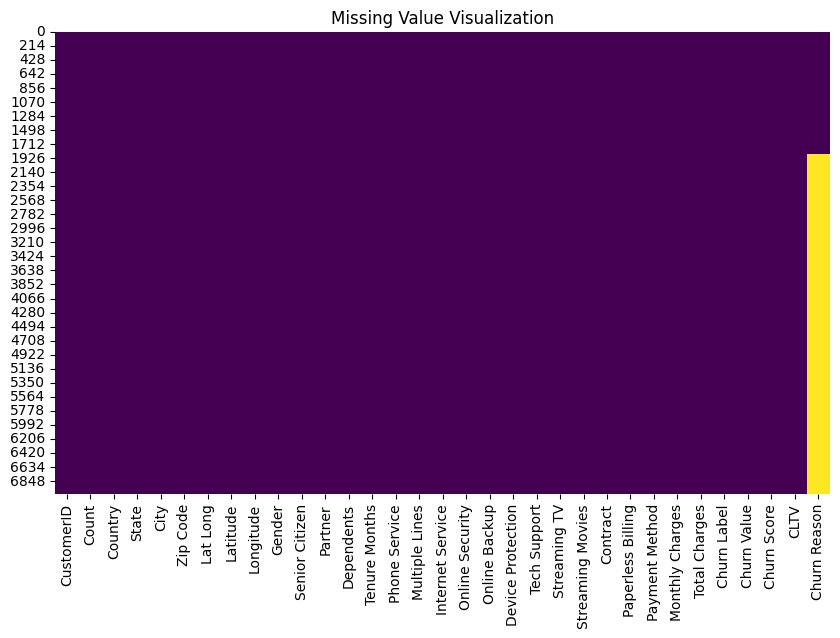

In [6]:

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Visualization')
plt.show()

In [7]:

df['Count'].value_counts()

Count
1    7043
Name: count, dtype: int64

In [8]:
df = df.drop(columns='Count')


In [9]:


df = df.drop(columns='Churn Reason')

In [10]:
df.Country.value_counts()

Country
United States    7043
Name: count, dtype: int64

In [11]:
df = df.drop(columns='Country')

In [12]:
df.State.value_counts()

State
California    7043
Name: count, dtype: int64

In [13]:
df = df.drop(columns='State')

In [14]:
# Convert 'Total Charges' to numeric, errors='coerce' will turn non-numeric values into NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Handle missing values in Total Charges (NaNs)
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

In [15]:
df.isnull().sum()

CustomerID           0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
dtype: int64

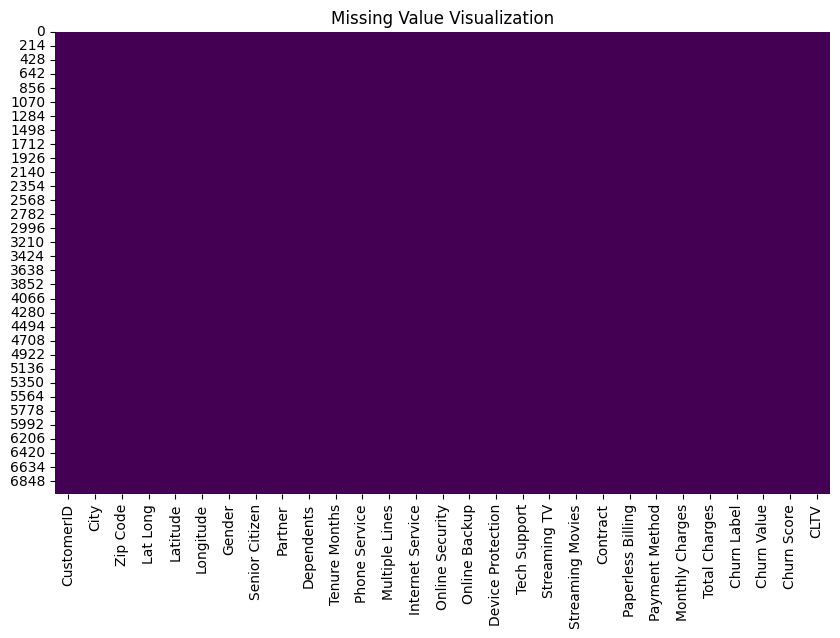

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Visualization')
plt.show()

In [17]:
df.describe()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,2281.916928,0.265370,58.699418,4400.295755
std,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.270398,0.441561,21.525131,1183.057152
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


Visualization

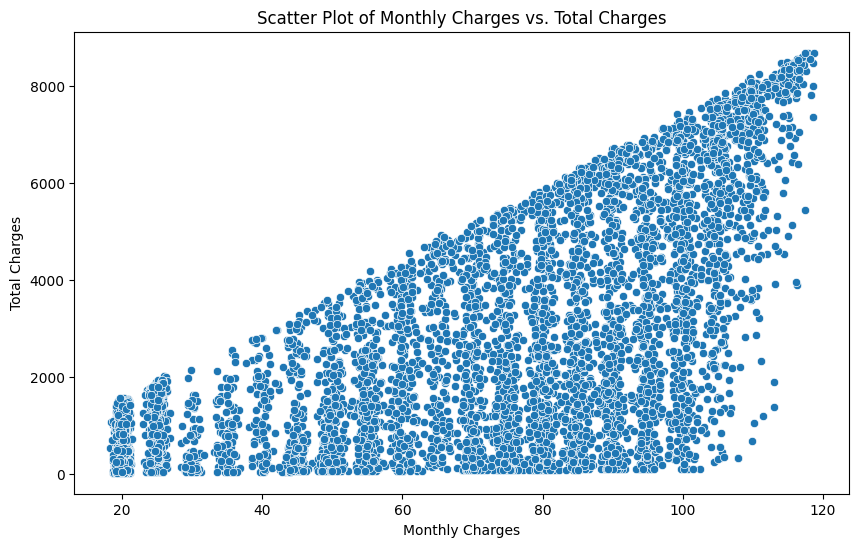

In [18]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Monthly Charges', y='Total Charges', data=df)
plt.title('Scatter Plot of Monthly Charges vs. Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()

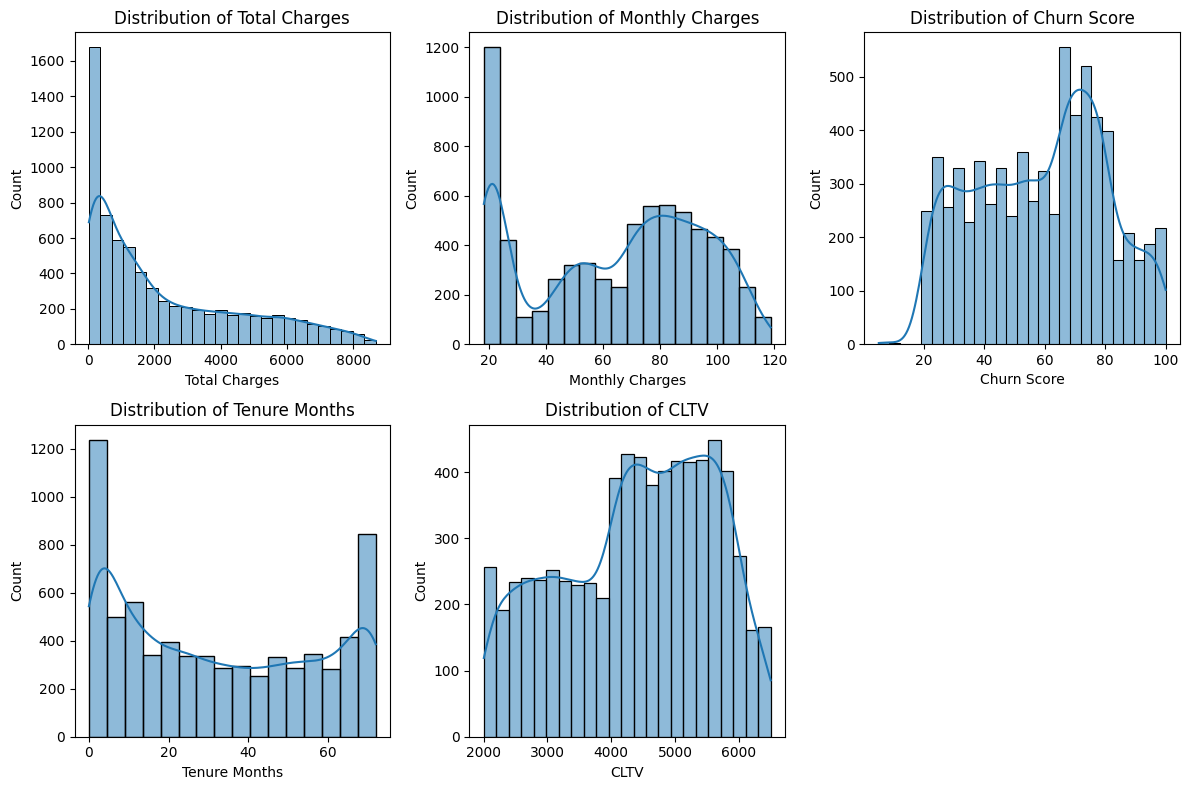

In [19]:
def distribution_numerical(data, x, index):
    plt.subplot(2, 3, index)
    sns.histplot(data=data, x=x, kde=True)
    plt.title(f"Distribution of {x}")  # Add a title for each subplot
    plt.tight_layout()

numerical_columns = ['Total Charges', 'Monthly Charges', 'Churn Score', 'Tenure Months', 'CLTV']

fig = plt.figure(figsize=(12, 8))

for index, col in enumerate(numerical_columns):
    distribution_numerical(df, col, index + 1)

plt.show()

In [20]:
!pip install plotly
import plotly.express as px

def generate_map_trace(data, color, width, height, title):
    """Generates a map trace using Plotly Express."""

    fig = px.scatter_geo(data,
                         lat='Latitude',
                         lon='Longitude',
                         color=color,
                         hover_name='CustomerID',  # You might need to adjust hover_name
                         projection="natural earth")

    fig.update_layout(title=title, width=width, height=height)
    fig.show()

# Now you can call the function as before:
churn_value = pd.DataFrame()

# Convert "Churn Value" to categorical if not already
churn_value["Churn Value"] = df["Churn Value"].map({0: "No Churn", 1: "Churn"})
churn_value[[col for col in df.columns if col != 'Churn Value']] = df[[col for col in df.columns if col != 'Churn Value']]

# Generate the maps with reduced size
color = 'Contract'
generate_map_trace(churn_value[churn_value['Churn Value'] == 'No Churn'],
                   color=color, width=900, height=500, title='Map with No Churn Values')
generate_map_trace(churn_value[churn_value['Churn Value'] == 'Churn'],
                   color=color, width=900, height=500, title='Map with only Churn Values')

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Count of customers who complete the purchase vs. those who churn:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Average spending by churn status:
Churn Label
No     2552.882494
Yes    1531.796094
Name: Total Charges, dtype: float64

Average spending by tenure for churned and non-churned customers:
    Churn Label  Tenure Months  Total Charges
0            No              0    1397.475000
1            No              1      37.909013
2            No              2      95.997391
3            No              3     152.135849
4            No              4     182.525806
..          ...            ...            ...
140         Yes             68    6720.550000
141         Yes             69    6887.931250
142         Yes             70    6803.995455
143         Yes             71    6765.908333
144         Yes             72    7039.150000

[145 rows x 3 columns]


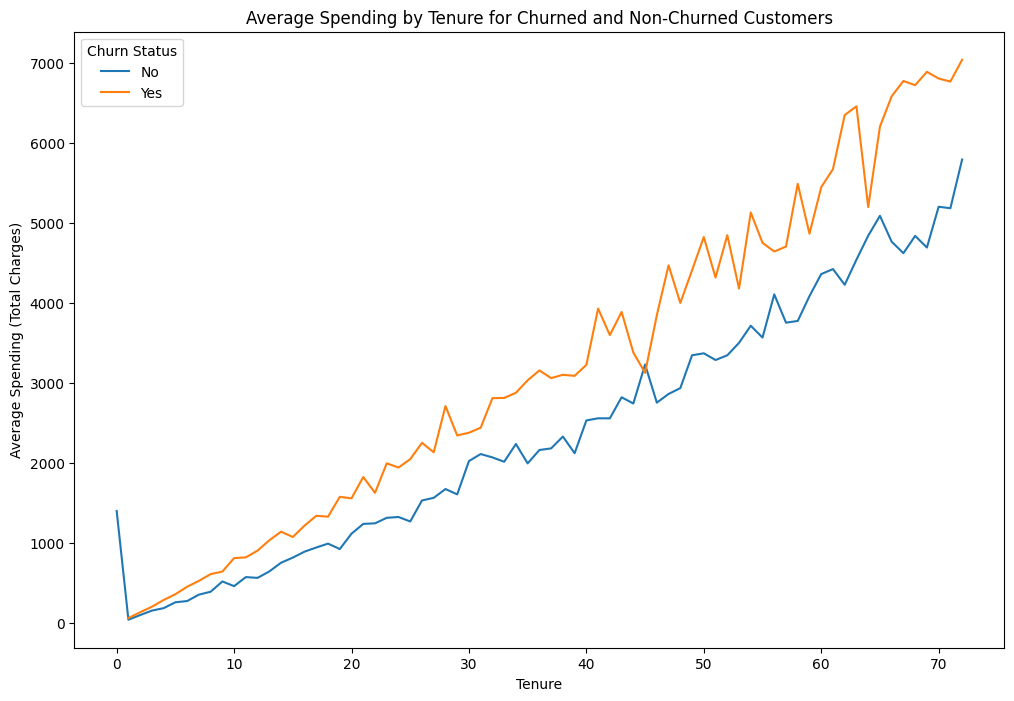

In [21]:
# Count of customers who complete the purchase versus those who do not
churn_counts = df['Churn Label'].value_counts()
print("Count of customers who complete the purchase vs. those who churn:")
print(churn_counts)

# Calculate average spending for customers based on churn status
average_charges_by_churn = df.groupby('Churn Label')['Total Charges'].mean()
print("\nAverage spending by churn status:")
print(average_charges_by_churn)

# Calculate average spending based on tenure for loyal and non-loyal customers
average_charges_by_tenure = df.groupby(['Churn Label', 'Tenure Months'])['Total Charges'].mean().reset_index()
print("\nAverage spending by tenure for churned and non-churned customers:")
print(average_charges_by_tenure)


df = df.replace([np.inf, -np.inf], np.nan)
plt.figure(figsize=(12, 8))
sns.lineplot(data=average_charges_by_tenure, x='Tenure Months', y='Total Charges', hue='Churn Label')
plt.title('Average Spending by Tenure for Churned and Non-Churned Customers')
plt.xlabel('Tenure')
plt.ylabel('Average Spending (Total Charges)')
plt.legend(title='Churn Status')
plt.show()

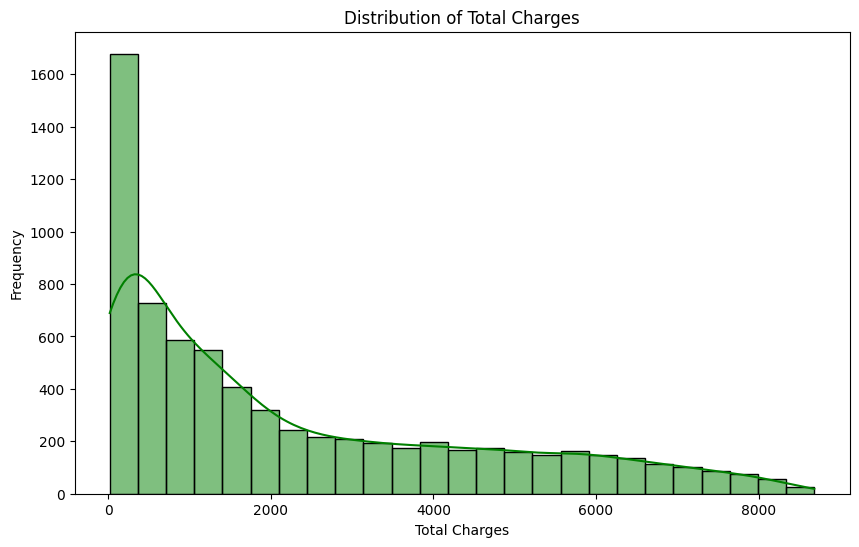

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Charges'], kde=True, color='green')
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

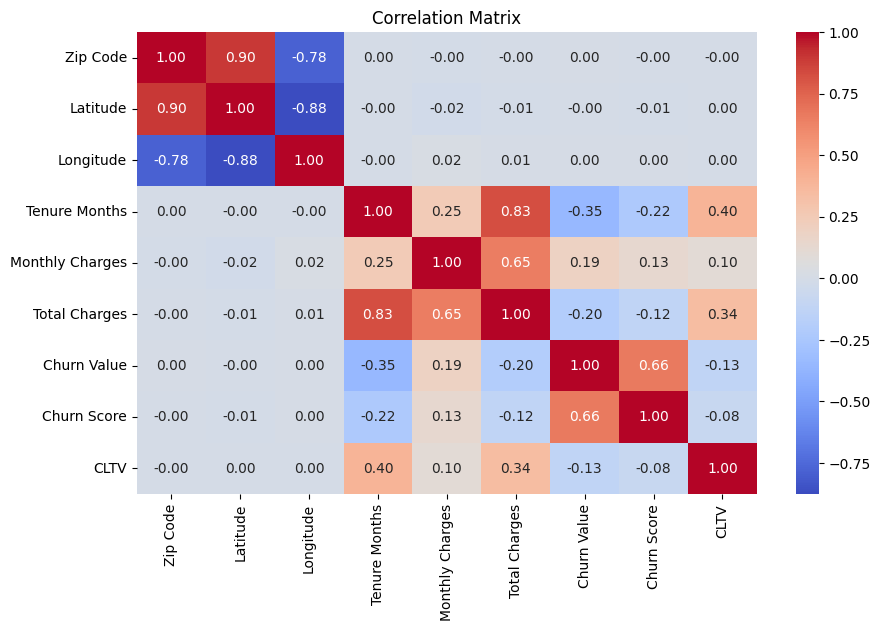

In [23]:
numeric_df = df.select_dtypes(include=[float, int])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Machine learning

In [24]:
# List of columns to apply LabelEncoder on

categorical_columns = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
    'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label'
]

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to all categorical columns
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Check the transformed data
print(df.head())

   CustomerID         City  Zip Code                Lat Long   Latitude  \
0  3668-QPYBK  Los Angeles     90003  33.964131, -118.272783  33.964131   
1  9237-HQITU  Los Angeles     90005   34.059281, -118.30742  34.059281   
2  9305-CDSKC  Los Angeles     90006  34.048013, -118.293953  34.048013   
3  7892-POOKP  Los Angeles     90010  34.062125, -118.315709  34.062125   
4  0280-XJGEX  Los Angeles     90015  34.039224, -118.266293  34.039224   

    Longitude  Gender  Senior Citizen  Partner  Dependents  ...  \
0 -118.272783       1               0        0           0  ...   
1 -118.307420       0               0        0           1  ...   
2 -118.293953       0               0        0           1  ...   
3 -118.315709       0               0        1           1  ...   
4 -118.266293       1               0        0           1  ...   

   Streaming Movies  Contract  Paperless Billing  Payment Method  \
0                 0         0                  1               3   
1         

In [25]:
# Define the feature columns (X)
X = df.drop(columns=['Churn Label', 'CustomerID', 'Churn Value','CustomerID', 'City','Zip Code','Lat Long'])

# Define the target column (y)
y = df['Churn Label']



In [26]:
X

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Score,CLTV
0,33.964131,-118.272783,1,0,0,0,2,1,0,0,...,0,0,0,0,1,3,53.85,108.15,86,3239
1,34.059281,-118.307420,0,0,0,1,2,1,0,1,...,0,0,0,0,1,2,70.70,151.65,67,2701
2,34.048013,-118.293953,0,0,0,1,8,1,2,1,...,0,2,2,0,1,2,99.65,820.50,86,5372
3,34.062125,-118.315709,0,0,1,1,28,1,2,1,...,2,2,2,0,1,2,104.80,3046.05,84,5003
4,34.039224,-118.266293,1,0,0,1,49,1,2,1,...,0,2,2,0,1,0,103.70,5036.30,89,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,34.341737,-116.539416,0,0,0,0,72,1,0,2,...,1,1,1,2,1,0,21.15,1419.40,45,5306
7039,34.667815,-117.536183,1,0,1,1,24,1,2,0,...,2,2,2,1,1,3,84.80,1990.50,59,2140
7040,34.559882,-115.637164,0,0,1,1,72,1,2,1,...,0,2,2,1,1,1,103.20,7362.90,71,5560
7041,34.167800,-116.864330,0,0,1,1,11,0,1,0,...,0,0,0,0,1,2,29.60,346.45,59,2793


In [27]:
# prompt: apply standarazation on X and make a dataframe with same column name as X

# Assuming X is defined as in the provided code

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with the scaled data and original column names
X= pd.DataFrame(X_scaled, columns=X.columns)


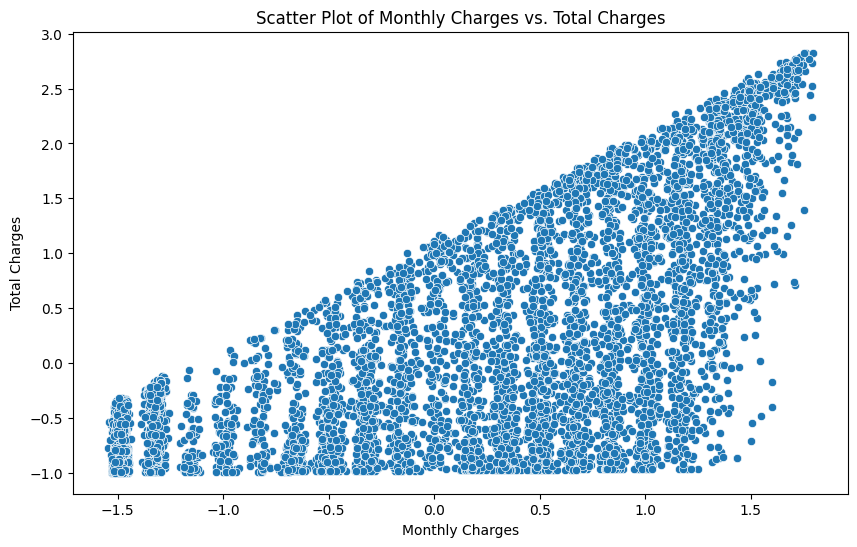

In [28]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Monthly Charges', y='Total Charges', data=X)
plt.title('Scatter Plot of Monthly Charges vs. Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Latitude           7043 non-null   float64
 1   Longitude          7043 non-null   float64
 2   Gender             7043 non-null   float64
 3   Senior Citizen     7043 non-null   float64
 4   Partner            7043 non-null   float64
 5   Dependents         7043 non-null   float64
 6   Tenure Months      7043 non-null   float64
 7   Phone Service      7043 non-null   float64
 8   Multiple Lines     7043 non-null   float64
 9   Internet Service   7043 non-null   float64
 10  Online Security    7043 non-null   float64
 11  Online Backup      7043 non-null   float64
 12  Device Protection  7043 non-null   float64
 13  Tech Support       7043 non-null   float64
 14  Streaming TV       7043 non-null   float64
 15  Streaming Movies   7043 non-null   float64
 16  Contract           7043 

In [31]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: Churn Label
Non-Null Count  Dtype
--------------  -----
7043 non-null   int64
dtypes: int64(1)
memory usage: 55.1 KB


In [32]:

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "KNN Classifier": KNeighborsClassifier(),
    "SVM/SVC": SVC()
}


results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    results[name] = {
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
    }

# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_train = linear_reg.predict(X_train)
y_pred_test = linear_reg.predict(X_test)

# Convert predictions to binary classes (0 or 1) for accuracy calculation
y_pred_train_bin = (y_pred_train > 0.5).astype(int) # Adjust threshold as needed
y_pred_test_bin = (y_pred_test > 0.5).astype(int) # Adjust threshold as needed

train_accuracy = accuracy_score(y_train, y_pred_train_bin)
test_accuracy = accuracy_score(y_test, y_pred_test_bin)

results["Linear Regression"] = {
    "train_accuracy": train_accuracy,
    "test_accuracy": test_accuracy
}


# KNN Regressor
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train, y_train)
y_pred_train = knn_regressor.predict(X_train)
y_pred_test = knn_regressor.predict(X_test)

y_pred_train_bin = (y_pred_train > 0.5).astype(int)
y_pred_test_bin = (y_pred_test > 0.5).astype(int)

train_accuracy = accuracy_score(y_train, y_pred_train_bin)
test_accuracy = accuracy_score(y_test, y_pred_test_bin)

results["KNN Regressor"] = {
    "train_accuracy": train_accuracy,
    "test_accuracy": test_accuracy
}


# Print the results
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"  Test Accuracy: {metrics['test_accuracy']:.4f}")
    print("-" * 20)

Decision Tree:
  Train Accuracy: 1.0000
  Test Accuracy: 0.8971
--------------------
Naive Bayes:
  Train Accuracy: 0.8777
  Test Accuracy: 0.8652
--------------------
Logistic Regression:
  Train Accuracy: 0.9253
  Test Accuracy: 0.9113
--------------------
Random Forest:
  Train Accuracy: 1.0000
  Test Accuracy: 0.9276
--------------------
KNN Classifier:
  Train Accuracy: 0.9049
  Test Accuracy: 0.8581
--------------------
SVM/SVC:
  Train Accuracy: 0.9411
  Test Accuracy: 0.9141
--------------------
Linear Regression:
  Train Accuracy: 0.9200
  Test Accuracy: 0.9099
--------------------
KNN Regressor:
  Train Accuracy: 0.9049
  Test Accuracy: 0.8581
--------------------


Applying ANN

In [33]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [34]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.20))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model with binary crossentropy loss
history = model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1, validation_data=(X_val, y_val))

# Predict using the trained model
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Evaluate the accuracy and confusion matrix
accuracy = accuracy_score(y_test, y_pred_classes)
confusion = confusion_matrix(y_test, y_pred_classes)
score = model.evaluate(X_test, y_test, verbose=0)

# Print evaluation results
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{confusion}")
print(f"Model Score: {score}")

Epoch 1/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7140 - loss: 0.5610 - val_accuracy: 0.8598 - val_loss: 0.3139
Epoch 2/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8748 - loss: 0.3058 - val_accuracy: 0.9051 - val_loss: 0.2236
Epoch 3/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8937 - loss: 0.2490 - val_accuracy: 0.9193 - val_loss: 0.1973
Epoch 4/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9018 - loss: 0.2282 - val_accuracy: 0.9184 - val_loss: 0.1927
Epoch 5/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9046 - loss: 0.2169 - val_accuracy: 0.9228 - val_loss: 0.1859
Epoch 6/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9099 - loss: 0.2097 - val_accuracy: 0.9157 - val_loss: 0.1849
Epoch 7/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9144 - loss: 0.1961 - val_accuracy: 0.9184 - val_loss: 0.1845
Epoch 8/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9175 - loss: 0.1892 - val_accu

In [35]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


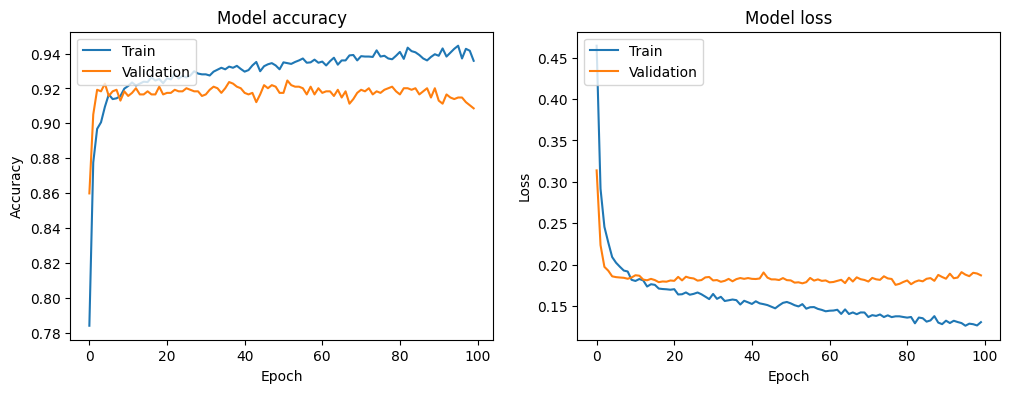

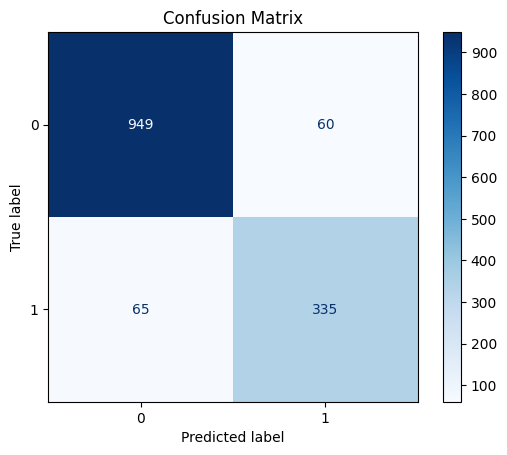

In [36]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()